#  1.Import Libraries & Setup

## Cách chạy notebook này

Notebook được chỉnh để **không phụ thuộc vào Google Drive/MyDrive của một cá nhân**.  
Khi chạy trên Colab, notebook sẽ tự tải project từ thư mục Google Drive chia sẻ vào `/content/BNPL_Churn`.

> Yêu cầu: thư mục Drive phải được đặt quyền **Anyone with the link → Viewer** để người khác có thể chạy notebook.


In [1]:
# 1. Import Libraries & Portable Setup
# Notebook này không phụ thuộc vào đường dẫn MyDrive cá nhân.
# Dữ liệu/project được tải từ thư mục Google Drive chia sẻ bằng link.

!pip -q install gdown

import os
import warnings
from pathlib import Path

import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Public/shared Google Drive folder của project
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1koMI5B9TD3plbtBucDsyp1C4qPNrhaTS?usp=drive_link"

# Working directory local của Colab
BASE_DIR = Path("/content/BNPL_Churn")
BASE_DIR.mkdir(parents=True, exist_ok=True)

# Chỉ tải khi chưa có dữ liệu
data_dir = BASE_DIR / "data"
if not data_dir.exists():
    print("Đang tải project từ Google Drive...")
    gdown.download_folder(
        url=DRIVE_FOLDER_URL,
        output=str(BASE_DIR),
        quiet=False,
        use_cookies=False,
    )
else:
    print("Project đã tồn tại trong runtime, bỏ qua bước tải.")

print("✅ Setup môi trường thành công!")
print("Working directory:", BASE_DIR)


# 2.Load Data & Preprocessing

In [2]:
# 2. Load Data & Preprocessing

# gdown có thể tạo thêm 1 lớp thư mục tùy tên folder Drive.
# Tự tìm thư mục data để notebook chạy được với mọi người.
candidate_data_dirs = list(BASE_DIR.rglob("data"))

if not candidate_data_dirs:
    raise FileNotFoundError(
        "Không tìm thấy thư mục `data` sau khi tải project. "
        "Hãy kiểm tra quyền chia sẻ Google Drive: Anyone with the link → Viewer."
    )

DATA_DIR = candidate_data_dirs[0]
print("DATA_DIR =", DATA_DIR)

tx = pd.read_csv(DATA_DIR / "bnpl_transactions_clean.csv",
                 parse_dates=["transaction_date"])

cust = pd.read_csv(DATA_DIR / "bnpl_customers_clean.csv",
                   parse_dates=["activation_date"])

feat = pd.read_csv(
    DATA_DIR / "bnpl_customer_features.csv",
    parse_dates=["activation_date", "first_trx_date", "last_trx_date"],
)

OBS_DATE = pd.Timestamp("2024-12-30")
CHURN_COL = "churn_60d"

print(
    f"Giao dịch : {len(tx):,} | "
    f"{tx.transaction_date.min():%d/%m/%Y} → {tx.transaction_date.max():%d/%m/%Y}"
)
print(
    f"Khách hàng: {len(cust):,} | "
    f"có giao dịch: {tx.customer_id.nunique():,}"
)

tx.head()


DATA_DIR = /home/claude/BNPL_Churn_local/data


Giao dịch : 64,746 | 01/01/2024 → 29/12/2024
Khách hàng: 8,000 | có giao dịch: 7,024


,transaction_id,customer_id,transaction_date,payment_category,payment_mode,amount_vnd,repayment_status,promo_applied,is_suspicious_flag,ym,has_suspicious
0,TRX00000001,ZLP000002,2024-01-07 22:06:50,Chăm sóc sức khỏe,ZaloPay Balance,392000.0,OnTime,No Promo,0,2024-01,0
1,TRX00000002,ZLP000002,2024-02-11 23:26:01,Chăm sóc sức khỏe,ZaloPay Balance,153000.0,OnTime,No Promo,0,2024-02,0
2,TRX00000003,ZLP000002,2024-03-20 19:27:27,Chăm sóc sức khỏe,ZaloPay Balance,472000.0,OnTime,No Promo,0,2024-03,0
3,TRX00000004,ZLP000002,2024-05-05 09:49:56,Chăm sóc sức khỏe,Auto-debit,208000.0,OnTime,No Promo,0,2024-05,0
4,TRX00000005,ZLP000002,2024-05-30 12:35:00,Chăm sóc sức khỏe,Manual,532000.0,OnTime,Cashback,0,2024-05,0


# 3.Exploratory Data Analysis (EDA) & Cohort

In [3]:

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="DejaVu Sans")

BASE_DIR = str(BASE_DIR)
FIG_DIR = f"{BASE_DIR}/reports/figures"
REPORTS_DIR = f"{BASE_DIR}/reports"
import os
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Giao dịch : {len(tx):,} | {tx.transaction_date.min():%d/%m/%Y} → {tx.transaction_date.max():%d/%m/%Y}")
print(f"Khách hàng: {len(cust):,} (đăng ký) | {tx.customer_id.nunique():,} có ít nhất 1 giao dịch")
print(f"Mốc quan sát: {OBS_DATE:%d/%m/%Y} | Nhãn churn: {CHURN_COL} (recency ≥ 60 ngày)")
tx.head(3)

Giao dịch : 64,746 | 01/01/2024 → 29/12/2024
Khách hàng: 8,000 (đăng ký) | 7,024 có ít nhất 1 giao dịch
Mốc quan sát: 30/12/2024 | Nhãn churn: churn_60d (recency ≥ 60 ngày)


,transaction_id,customer_id,transaction_date,payment_category,payment_mode,amount_vnd,repayment_status,promo_applied,is_suspicious_flag,ym,has_suspicious
0,TRX00000001,ZLP000002,2024-01-07 22:06:50,Chăm sóc sức khỏe,ZaloPay Balance,392000.0,OnTime,No Promo,0,2024-01,0
1,TRX00000002,ZLP000002,2024-02-11 23:26:01,Chăm sóc sức khỏe,ZaloPay Balance,153000.0,OnTime,No Promo,0,2024-02,0
2,TRX00000003,ZLP000002,2024-03-20 19:27:27,Chăm sóc sức khỏe,ZaloPay Balance,472000.0,OnTime,No Promo,0,2024-03,0


## 1. Xác định tập phân tích cohort — xử lý hiện tượng cắt cụt bên trái (left truncation)

⚠️ **Vấn đề cần xử lý trước khi dựng cohort.** Log giao dịch chỉ bắt đầu từ 01/01/2024, trong khi
`activation_date` của khách hàng trải từ 01/2023. Hệ quả: mọi khách kích hoạt trong năm 2023 đều có
"giao dịch đầu tiên quan sát được" rơi vào tháng 01/2024 — nhưng đó **không phải** giao dịch đầu tiên
thật sự của họ. Nếu gộp chung, cohort tháng 01/2024 sẽ là hỗn hợp giữa khách thật sự mới và khách đã
gắn bó cả năm, làm sai lệch toàn bộ ma trận retention.

**Cách xử lý:** chỉ đưa vào phân tích cohort những khách hàng **kích hoạt từ 01/01/2024 trở đi** — nhóm
có toàn bộ vòng đời nằm trong cửa sổ dữ liệu. Nhóm kích hoạt trước 2024 được báo cáo riêng ở mức tham khảo.

In [4]:
tx["txn_month"] = tx.transaction_date.dt.to_period("M")
first_txn = tx.groupby("customer_id")["transaction_date"].min()

has_txn = feat[feat.lifecycle_segment != "No_Transaction"].copy()
truncated = has_txn[has_txn.activation_date < "2024-01-01"]
cohort_pool = has_txn[has_txn.activation_date >= "2024-01-01"]

print(f"Khách có giao dịch                     : {len(has_txn):,}")
print(f"  ├─ kích hoạt TRƯỚC 2024 (bị cắt cụt) : {len(truncated):,} ({len(truncated)/len(has_txn):.1%}) → loại khỏi cohort")
print(f"  └─ kích hoạt trong 2024 (dùng cohort): {len(cohort_pool):,} ({len(cohort_pool)/len(has_txn):.1%})")
print(f"\nKhách đăng ký nhưng CHƯA từng giao dịch: {(feat.lifecycle_segment == 'No_Transaction').sum():,}"
      f" — nhóm 'kích hoạt hụt', phân tích riêng ở mục 3.3.2")

tx_c = tx[tx.customer_id.isin(cohort_pool.customer_id)].copy()
tx_c["cohort_month"] = tx_c.customer_id.map(first_txn.dt.to_period("M"))
tx_c["period_index"] = (tx_c.txn_month - tx_c.cohort_month).apply(lambda p: p.n)

cohort_sizes = tx_c.groupby("cohort_month")["customer_id"].nunique().rename("Quy mô cohort")
cohort_sizes.to_frame().T

Khách có giao dịch                     : 7,024
  ├─ kích hoạt TRƯỚC 2024 (bị cắt cụt) : 3,069 (43.7%) → loại khỏi cohort
  └─ kích hoạt trong 2024 (dùng cohort): 3,955 (56.3%)

Khách đăng ký nhưng CHƯA từng giao dịch: 976 — nhóm 'kích hoạt hụt', phân tích riêng ở mục 3.3.2


cohort_month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
Quy mô cohort,728,316,407,401,411,349,380,318,264,118,181,82


## 2. Ma trận Cohort MoM Retention (Cohort Triangle) — mục 3.3.3

`Retention(c, n)` = số khách của cohort *c* còn phát sinh giao dịch ở tháng thứ *n* ÷ quy mô cohort *c*.
Theo định nghĩa, cột tháng 0 luôn bằng 100%.

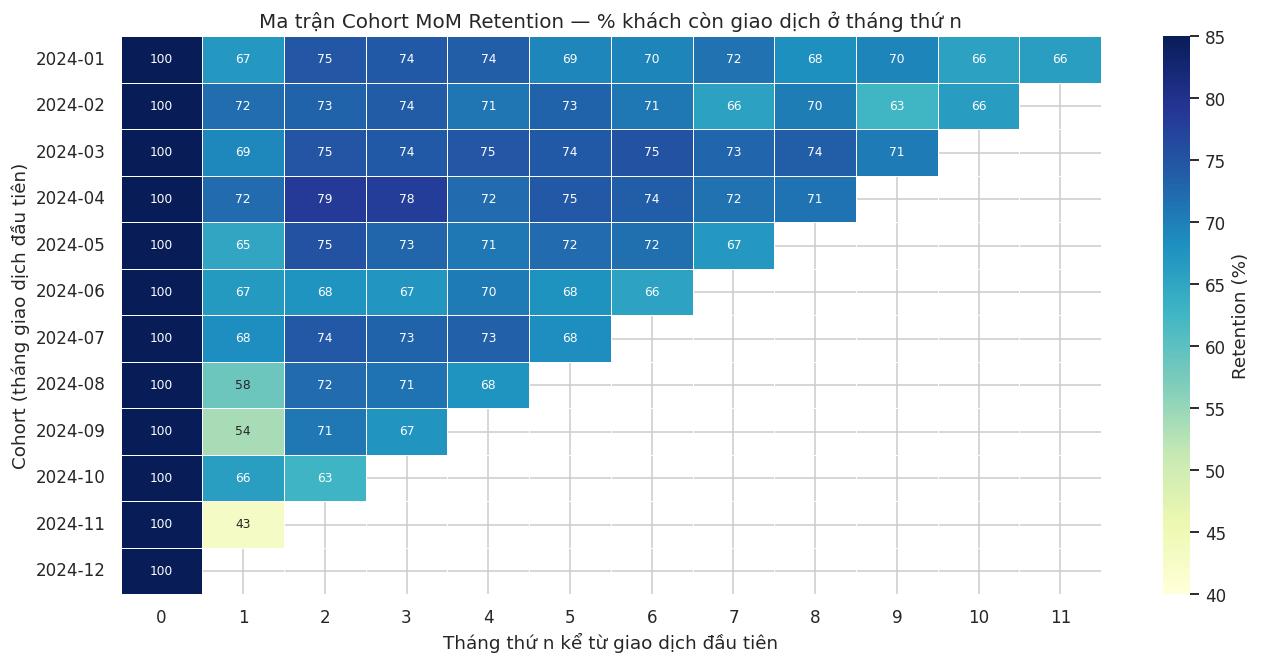

Quy mô từng cohort: {Period('2024-01', 'M'): 728, Period('2024-02', 'M'): 316, Period('2024-03', 'M'): 407, Period('2024-04', 'M'): 401, Period('2024-05', 'M'): 411, Period('2024-06', 'M'): 349, Period('2024-07', 'M'): 380, Period('2024-08', 'M'): 318, Period('2024-09', 'M'): 264, Period('2024-10', 'M'): 118, Period('2024-11', 'M'): 181, Period('2024-12', 'M'): 82}


In [5]:
active = (tx_c.groupby(["cohort_month", "period_index"])["customer_id"]
              .nunique().reset_index(name="n_active"))
retention = active.pivot(index="cohort_month", columns="period_index", values="n_active")
retention_pct = retention.divide(cohort_sizes, axis=0) * 100

fig, ax = plt.subplots(figsize=(12.5, 6.2))
sns.heatmap(retention_pct, annot=True, fmt=".0f", cmap="YlGnBu", vmin=40, vmax=85,
            cbar_kws={"label": "Retention (%)"}, annot_kws={"size": 8}, linewidths=0.4, ax=ax)
ax.set_title("Ma trận Cohort MoM Retention — % khách còn giao dịch ở tháng thứ n", fontsize=13)
ax.set_xlabel("Tháng thứ n kể từ giao dịch đầu tiên")
ax.set_ylabel("Cohort (tháng giao dịch đầu tiên)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cohort_retention_heatmap.png", bbox_inches="tight")
plt.show()

print("Quy mô từng cohort:", cohort_sizes.to_dict())

**Cách đọc ma trận (đưa vào mục 3.3.3):**
- **Theo hàng** — đường cong "sống sót" của một thế hệ khách hàng theo vòng đời.
- **Theo cột** — so sánh chất lượng các cohort ở cùng độ tuổi (cohort nào giữ chân tốt hơn).
- **Theo đường chéo** — hiệu ứng thời gian lịch (mùa vụ, chiến dịch) tác động lên mọi cohort cùng lúc.

⚠️ Các cohort tháng 10–12/2024 bị **cắt cụt bên phải (right-censored)** — chỉ quan sát được 1–3 tháng
vòng đời, đồng thời quy mô nhỏ, nên chỉ dùng ở mức tham khảo (đúng lưu ý đã ghi ở mục 2.2.1c).

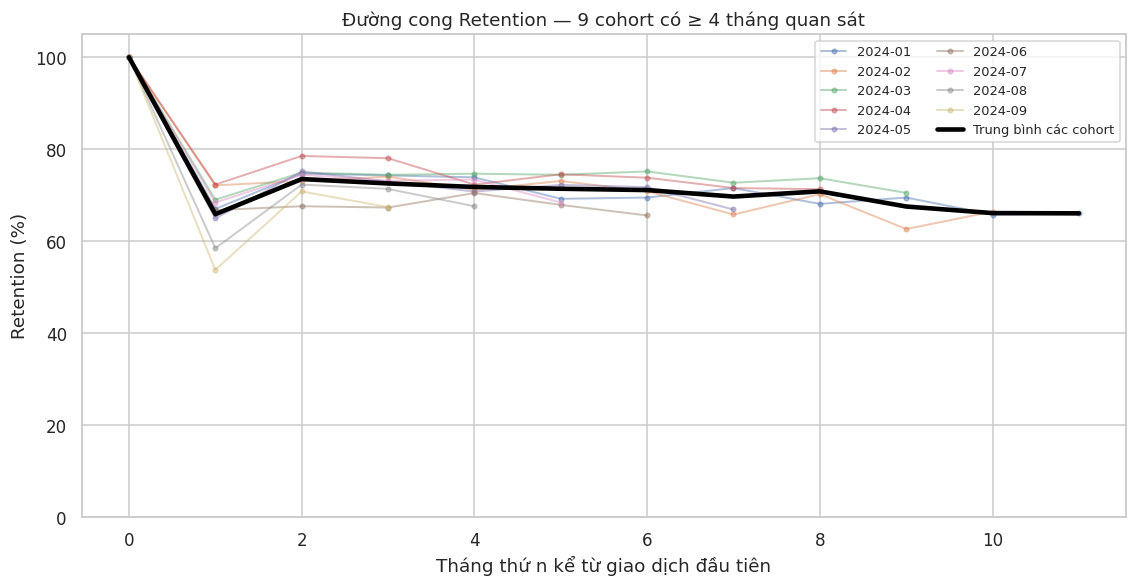

Retention trung bình — tháng 1: 65.9% | tháng 3: 72.6% | tháng 6: 71.1%
→ Sụt giảm lớn nhất diễn ra ngay trong tháng đầu: mất 34.1% khách của cohort.
→ Sau đó đường cong đi ngang quanh mức 72% — nhóm vượt qua tháng đầu có xu hướng ở lại lâu dài.


In [6]:
MATURE_MIN_PERIODS = 4      # cohort "chín" = quan sát được ít nhất 4 tháng vòng đời
# (giảm từ 6 xuống 4 để giữ đủ cohort trong dataset 12 tháng; Jan–Aug 2024 đều qualify)
mature = retention_pct[retention_pct.notna().sum(axis=1) >= MATURE_MIN_PERIODS]
mean_curve = mature.mean(axis=0)

fig, ax = plt.subplots(figsize=(10.5, 5.5))
for c in mature.index:
    ax.plot(mature.columns, mature.loc[c], alpha=0.45, lw=1.3, marker="o", ms=3, label=str(c))
ax.plot(mean_curve.index, mean_curve.values, color="black", lw=3, label="Trung bình các cohort")
ax.set_ylim(0, 105)
ax.set_xlabel("Tháng thứ n kể từ giao dịch đầu tiên")
ax.set_ylabel("Retention (%)")
ax.set_title(f"Đường cong Retention — {len(mature)} cohort có ≥ {MATURE_MIN_PERIODS} tháng quan sát")
ax.legend(ncol=2, fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cohort_retention_curves.png", bbox_inches="tight")
plt.show()

m1, m3, m6 = (float(mean_curve.get(k, np.nan)) for k in (1, 3, 6))
print(f"Retention trung bình — tháng 1: {m1:.1f}% | tháng 3: {m3:.1f}% | tháng 6: {m6:.1f}%")
print(f"→ Sụt giảm lớn nhất diễn ra ngay trong tháng đầu: mất {100 - m1:.1f}% khách của cohort.")
print(f"→ Sau đó đường cong đi ngang quanh mức {mean_curve[2:7].mean():.0f}% — nhóm vượt qua tháng đầu "
      f"có xu hướng ở lại lâu dài.")

### 2.1. Kiểm chứng: retention theo cửa sổ 30 ngày neo tại từng khách hàng

Cohort theo **tháng lịch** có một nhược điểm đã biết: khách giao dịch lần đầu vào cuối tháng chỉ còn vài
ngày của "tháng 0", nên dễ bị tính là mất ở tháng 1 dù thực tế họ quay lại sau 3–4 tuần. Để loại trừ
khả năng cú sụt ở tháng 1 chỉ là *ảo ảnh do cách chia tháng*, ta tính lại retention theo **cửa sổ 30 ngày
neo tại ngày giao dịch đầu tiên của chính khách hàng đó**, và chỉ đưa vào mẫu số những khách đã được
quan sát đủ cửa sổ tương ứng.

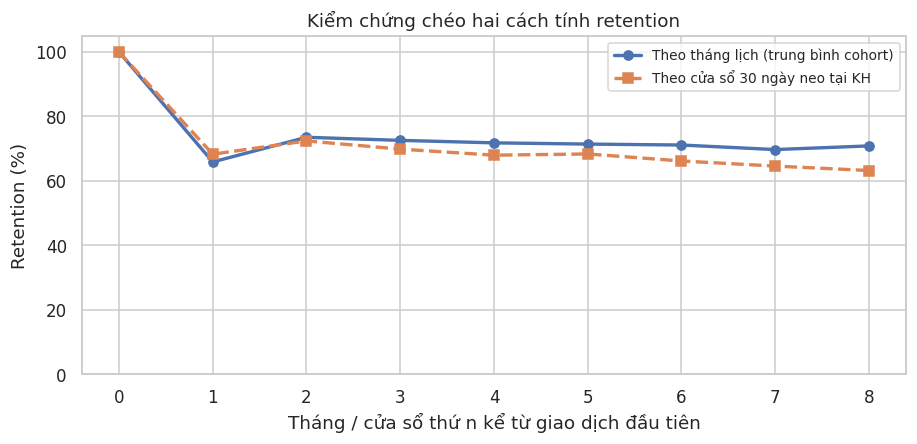

Retention theo cửa sổ 30 ngày: {0: 100.0, 1: 68.3, 2: 72.4, 3: 69.9, 4: 68.0, 5: 68.4, 6: 66.2, 7: 64.6, 8: 63.2}
→ Hai cách tính cho cùng một hình dạng (sụt ở kỳ 1 rồi đi ngang) ⇒ cú sụt tháng đầu là **đặc điểm thật của dữ liệu**, không phải ảo ảnh do chia tháng lịch.


In [7]:
tx_c["win_index"] = ((tx_c.transaction_date - tx_c.customer_id.map(first_txn)).dt.days // 30).astype(int)
obs_windows = ((OBS_DATE - first_txn.loc[cohort_pool.customer_id.values]).dt.days // 30)

win_curve = {}
for n in range(0, 9):
    eligible = obs_windows[obs_windows >= n].index
    n_active = tx_c[(tx_c.win_index == n) & (tx_c.customer_id.isin(eligible))].customer_id.nunique()
    win_curve[n] = n_active / len(eligible) * 100 if len(eligible) else np.nan
win_curve = pd.Series(win_curve)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(mean_curve.index[:9], mean_curve.values[:9], marker="o", lw=2.2,
        label="Theo tháng lịch (trung bình cohort)")
ax.plot(win_curve.index, win_curve.values, marker="s", lw=2.2, ls="--",
        label="Theo cửa sổ 30 ngày neo tại KH")
ax.set_ylim(0, 105)
ax.set_xlabel("Tháng / cửa sổ thứ n kể từ giao dịch đầu tiên")
ax.set_ylabel("Retention (%)")
ax.set_title("Kiểm chứng chéo hai cách tính retention")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/retention_crosscheck.png", bbox_inches="tight")
plt.show()

print("Retention theo cửa sổ 30 ngày:", win_curve.round(1).to_dict())
print(f"→ Hai cách tính cho cùng một hình dạng (sụt ở kỳ 1 rồi đi ngang) ⇒ cú sụt tháng đầu là "
      f"**đặc điểm thật của dữ liệu**, không phải ảo ảnh do chia tháng lịch.")

## 3. FPU vs RPU — mục 3.3.2

- **FPU (First Paying User)**: khách chỉ phát sinh **đúng 1** giao dịch BNPL.
- **RPU (Repeat Paying User)**: khách có **≥ 2** giao dịch; bộ dữ liệu chia tiếp thành
  `RPU_Early` (2–5 giao dịch), `RPU_Mid` (6–15) và `RPU_Loyal` (> 15).
- Ngoài ra còn nhóm **No_Transaction**: đã đăng ký/được cấp hạn mức nhưng chưa từng giao dịch —
  thất bại ở khâu kích hoạt, cần tách riêng khi tính tỷ lệ churn.

In [8]:
seg_order = ["No_Transaction", "FPU", "RPU_Early", "RPU_Mid", "RPU_Loyal"]
seg = (feat.groupby("lifecycle_segment")
           .agg(so_khach=("customer_id", "size"), churn_rate=(CHURN_COL, "mean"))
           .reindex(seg_order))
seg["ty_trong_%"] = (seg.so_khach / seg.so_khach.sum() * 100).round(1)
seg["churn_rate_%"] = (seg.churn_rate * 100).round(1)
seg = seg[["so_khach", "ty_trong_%", "churn_rate_%"]]

fpu_n = int(seg.loc["FPU", "so_khach"])
rpu_n = int(seg.loc[["RPU_Early", "RPU_Mid", "RPU_Loyal"], "so_khach"].sum())
print(f"FPU (đúng 1 giao dịch): {fpu_n:,} khách ({fpu_n/(fpu_n+rpu_n):.1%} số khách có giao dịch)")
print(f"RPU (≥ 2 giao dịch)   : {rpu_n:,} khách ({rpu_n/(fpu_n+rpu_n):.1%})")
print(f"Tỷ lệ chuyển đổi FPU → RPU: {rpu_n/(fpu_n+rpu_n):.1%}\n")
seg

FPU (đúng 1 giao dịch): 465 khách (6.6% số khách có giao dịch)
RPU (≥ 2 giao dịch)   : 6,559 khách (93.4%)
Tỷ lệ chuyển đổi FPU → RPU: 93.4%



,so_khach,ty_trong_%,churn_rate_%
lifecycle_segment,,,
No_Transaction,976,12.2,100.0
FPU,465,5.8,67.5
RPU_Early,1816,22.7,38.8
RPU_Mid,3882,48.5,5.4
RPU_Loyal,861,10.8,0.7


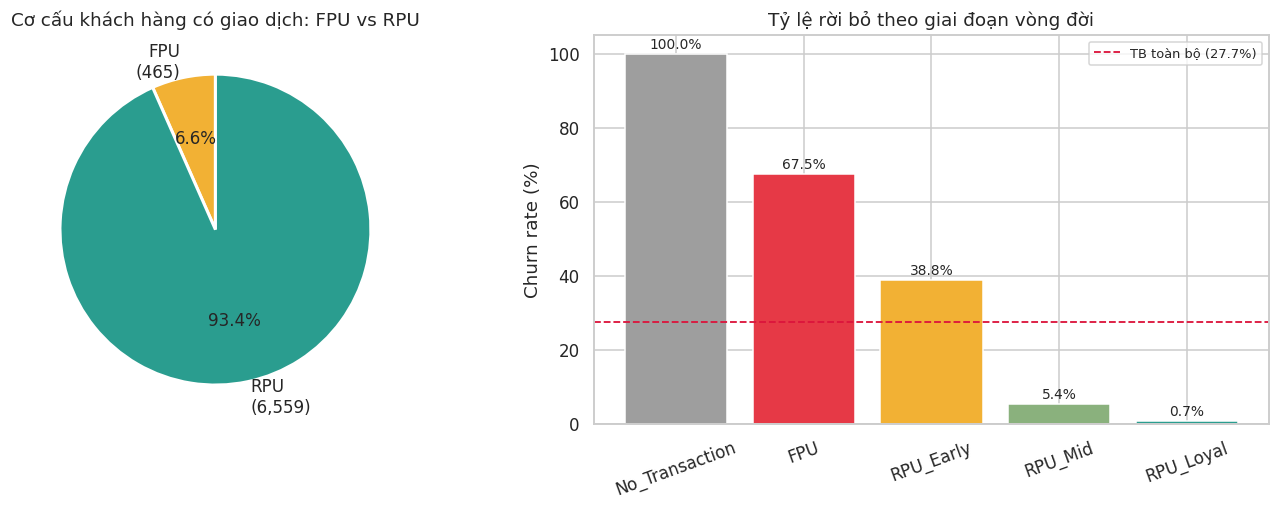

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].pie([fpu_n, rpu_n], labels=[f"FPU\n({fpu_n:,})", f"RPU\n({rpu_n:,})"],
            autopct="%1.1f%%", colors=["#f2b134", "#2a9d8f"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 11})
axes[0].set_title("Cơ cấu khách hàng có giao dịch: FPU vs RPU")

bars = axes[1].bar(seg.index, seg["churn_rate_%"],
                   color=["#9e9e9e", "#e63946", "#f2b134", "#8ab17d", "#2a9d8f"])
axes[1].axhline(feat[CHURN_COL].mean() * 100, color="crimson", ls="--", lw=1.2,
                label=f"TB toàn bộ ({feat[CHURN_COL].mean()*100:.1f}%)")
for b, v in zip(bars, seg["churn_rate_%"]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_title("Tỷ lệ rời bỏ theo giai đoạn vòng đời")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fpu_rpu_analysis.png", bbox_inches="tight")
plt.show()

### 3.1. Thời gian đến giao dịch thứ hai — chỉ báo sớm của retention

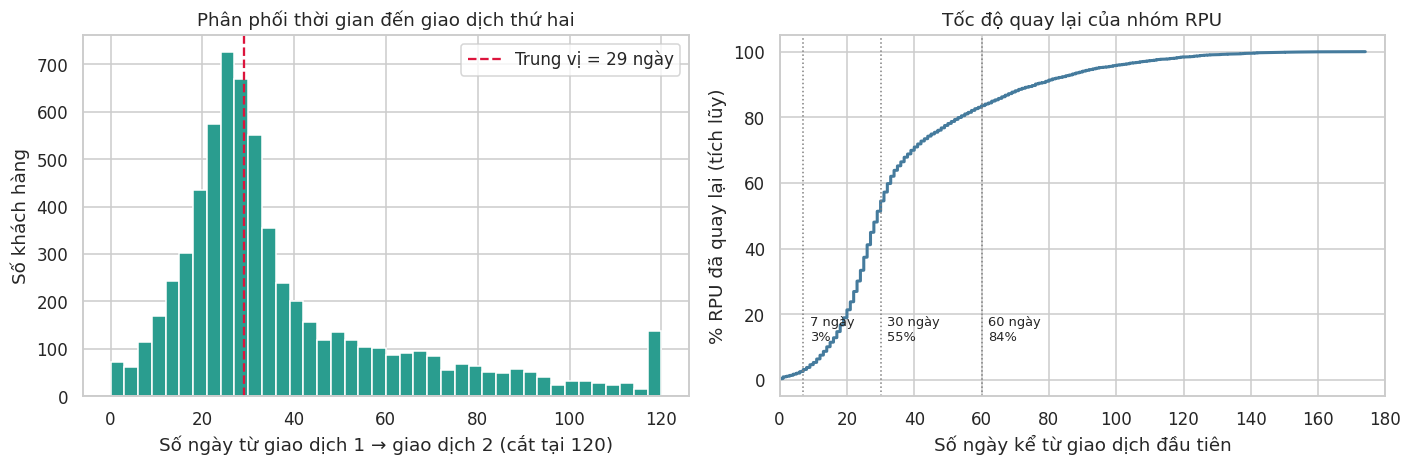

Thời gian đến giao dịch thứ 2 — trung vị 29 ngày | p75 46 ngày | p90 76 ngày
Tỷ lệ RPU quay lại trong 7 ngày: 3.2% | 30 ngày: 54.5% | 60 ngày: 83.5%


In [10]:
first_two = (tx.sort_values(["customer_id", "transaction_date"])
               .groupby("customer_id").head(2)
               .groupby("customer_id")["transaction_date"].agg(["first", "last"]))
first_two = first_two[first_two["first"] != first_two["last"]]   # chỉ giữ khách có ≥ 2 giao dịch
gap = (first_two["last"] - first_two["first"]).dt.days

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].hist(gap.clip(upper=120), bins=40, color="#2a9d8f", edgecolor="white")
axes[0].axvline(gap.median(), color="crimson", ls="--", lw=1.5,
                label=f"Trung vị = {gap.median():.0f} ngày")
axes[0].set_xlabel("Số ngày từ giao dịch 1 → giao dịch 2 (cắt tại 120)")
axes[0].set_ylabel("Số khách hàng")
axes[0].set_title("Phân phối thời gian đến giao dịch thứ hai")
axes[0].legend()

cum = np.arange(1, len(gap) + 1) / len(gap) * 100
axes[1].plot(np.sort(gap), cum, color="#457b9d", lw=2)
for d in (7, 30, 60):
    pct = (gap <= d).mean() * 100
    axes[1].axvline(d, color="grey", ls=":", lw=1)
    axes[1].text(d + 2, 12, f"{d} ngày\n{pct:.0f}%", fontsize=8.5)
axes[1].set_xlim(0, 180)
axes[1].set_xlabel("Số ngày kể từ giao dịch đầu tiên")
axes[1].set_ylabel("% RPU đã quay lại (tích lũy)")
axes[1].set_title("Tốc độ quay lại của nhóm RPU")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/time_to_second_purchase.png", bbox_inches="tight")
plt.show()

print(f"Thời gian đến giao dịch thứ 2 — trung vị {gap.median():.0f} ngày | "
      f"p75 {gap.quantile(0.75):.0f} ngày | p90 {gap.quantile(0.90):.0f} ngày")
print(f"Tỷ lệ RPU quay lại trong 7 ngày: {(gap <= 7).mean():.1%} | "
      f"30 ngày: {(gap <= 30).mean():.1%} | 60 ngày: {(gap <= 60).mean():.1%}")

## 4. Người dùng hoạt động hằng tháng (MAU): khách MỚI vs khách QUAY LẠI

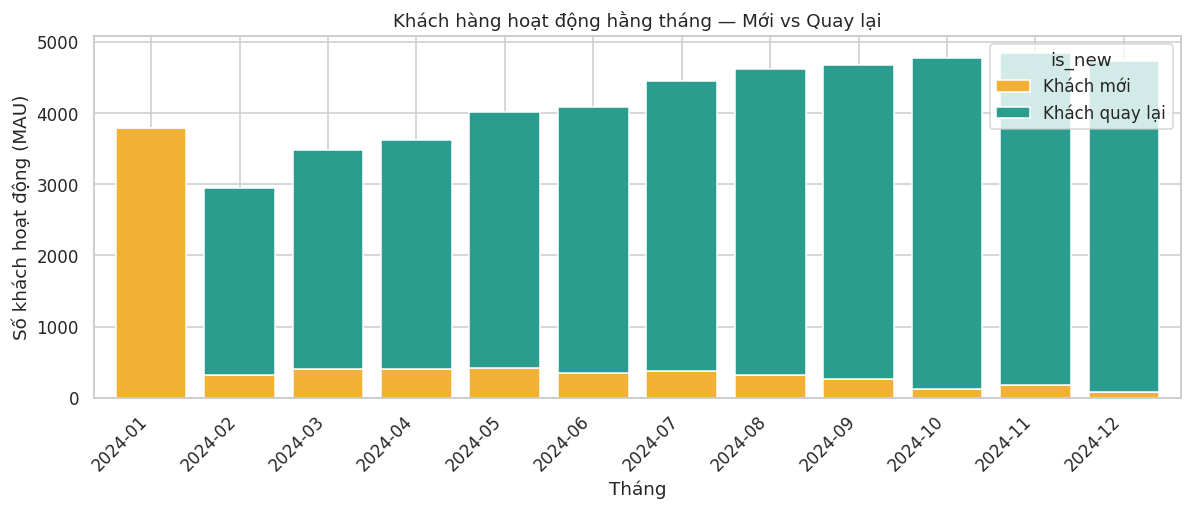

Tỷ trọng khách quay lại trong MAU (6 tháng cuối): {'2024-07': 91.5, '2024-08': 93.1, '2024-09': 94.4, '2024-10': 97.5, '2024-11': 96.3, '2024-12': 98.3}


In [11]:
tx["is_new"] = tx.customer_id.map(first_txn.dt.to_period("M")) == tx.txn_month
monthly = (tx.groupby(["txn_month", "is_new"])["customer_id"].nunique()
             .unstack(fill_value=0)
             .rename(columns={True: "Khách mới", False: "Khách quay lại"})[["Khách mới", "Khách quay lại"]])

ax = monthly.plot(kind="bar", stacked=True, figsize=(11, 4.8),
                  color=["#f2b134", "#2a9d8f"], width=0.8)
ax.set_title("Khách hàng hoạt động hằng tháng — Mới vs Quay lại")
ax.set_xlabel("Tháng"); ax.set_ylabel("Số khách hoạt động (MAU)")
ax.set_xticklabels([str(p) for p in monthly.index], rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/mau_new_vs_returning.png", bbox_inches="tight")
plt.show()

share = (monthly["Khách quay lại"] / monthly.sum(axis=1) * 100).round(1)
print("Tỷ trọng khách quay lại trong MAU (6 tháng cuối):",
      {str(k): v for k, v in share.tail(6).items()})

## 5. Retention theo danh mục thanh toán — insight chính của đề tài

Ghép chiều **danh mục** vào phân tích cohort: nhóm khách theo `top_category` (danh mục chi tiêu nhiều
nhất) rồi so sánh đường cong retention và tỷ lệ churn giữa các danh mục.

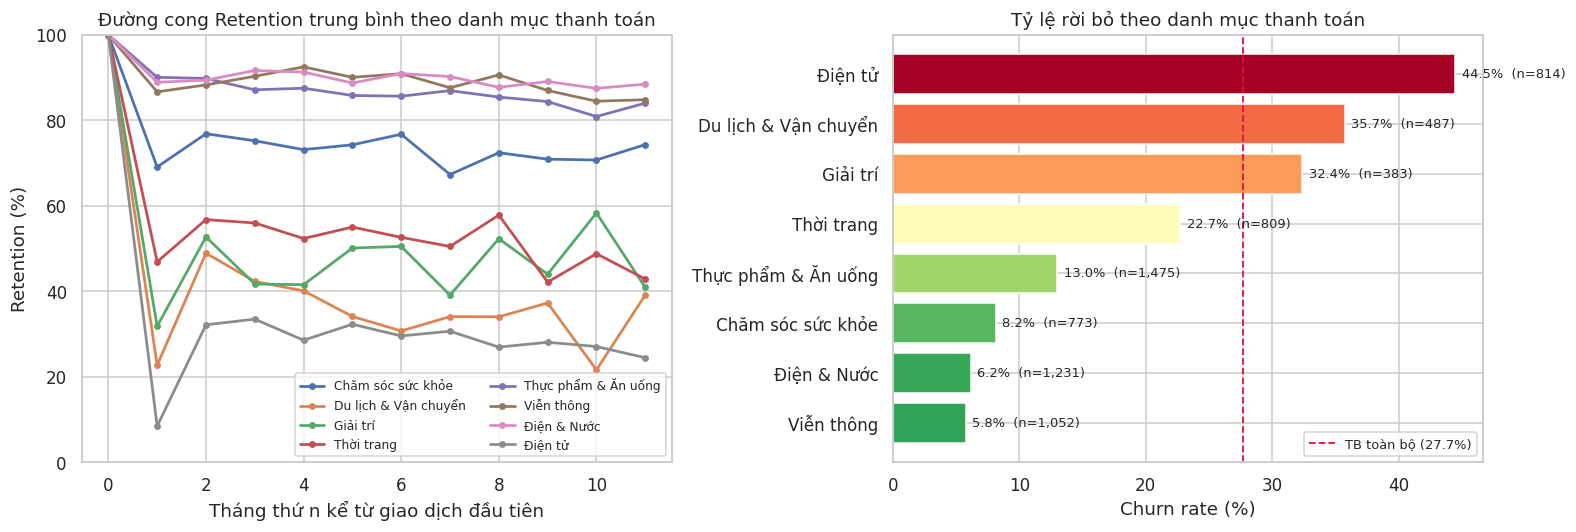

,churn_rate,n
top_category,,
Viễn thông,5.8,1052
Điện & Nước,6.2,1231
Chăm sóc sức khỏe,8.2,773
Thực phẩm & Ăn uống,13.0,1475
Thời trang,22.7,809
Giải trí,32.4,383
Du lịch & Vận chuyển,35.7,487
Điện tử,44.5,814


In [12]:
cat_of = feat.set_index("customer_id")["top_category"]
tx_c["cat"] = tx_c.customer_id.map(cat_of)

rows = []
for cat, grp in tx_c.groupby("cat"):
    size = grp.groupby("cohort_month")["customer_id"].nunique()
    act_ = grp.groupby(["cohort_month", "period_index"])["customer_id"].nunique().unstack()
    pct = (act_.divide(size, axis=0) * 100)
    pct = pct[pct.notna().sum(axis=1) >= MATURE_MIN_PERIODS]
    if len(pct):
        rows.append(pct.mean(axis=0).rename(cat))
cat_curves = pd.DataFrame(rows)

churn_by_cat = (feat.dropna(subset=["top_category"])
                    .groupby("top_category")[CHURN_COL]
                    .agg(churn_rate=lambda s: s.mean() * 100, n="size")
                    .sort_values("churn_rate"))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
for cat in cat_curves.index:
    axes[0].plot(cat_curves.columns, cat_curves.loc[cat], marker="o", ms=3.5, lw=1.8, label=cat)
axes[0].set_xlabel("Tháng thứ n kể từ giao dịch đầu tiên")
axes[0].set_ylabel("Retention (%)")
axes[0].set_title("Đường cong Retention trung bình theo danh mục thanh toán")
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_ylim(0, 100)

colors = plt.cm.RdYlGn_r(churn_by_cat.churn_rate / churn_by_cat.churn_rate.max())
axes[1].barh(churn_by_cat.index, churn_by_cat.churn_rate, color=colors)
axes[1].axvline(feat[CHURN_COL].mean() * 100, color="crimson", ls="--", lw=1.2,
                label=f"TB toàn bộ ({feat[CHURN_COL].mean()*100:.1f}%)")
for i, (v, n) in enumerate(zip(churn_by_cat.churn_rate, churn_by_cat.n)):
    axes[1].text(v + 0.5, i, f"{v:.1f}%  (n={n:,})", va="center", fontsize=8.5)
axes[1].set_xlabel("Churn rate (%)")
axes[1].set_title("Tỷ lệ rời bỏ theo danh mục thanh toán")
axes[1].legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/retention_by_category.png", bbox_inches="tight")
plt.show()

churn_by_cat.round(1)

## 6. Xuất số liệu cho báo cáo

In [13]:
retention_pct.round(1).to_csv(f"{REPORTS_DIR}/cohort_retention_matrix.csv", encoding="utf-8-sig")
seg.to_csv(f"{REPORTS_DIR}/lifecycle_segment_summary.csv", encoding="utf-8-sig")
churn_by_cat.round(2).to_csv(f"{REPORTS_DIR}/churn_by_category.csv", encoding="utf-8-sig")
cat_curves.round(1).to_csv(f"{REPORTS_DIR}/retention_curve_by_category.csv", encoding="utf-8-sig")

summary = {
    "So khach hang": len(feat),
    "So khach co giao dich": int(len(has_txn)),
    "So khach chua tung giao dich": int((feat.lifecycle_segment == "No_Transaction").sum()),
    "Churn rate toan bo (60d)": round(feat[CHURN_COL].mean() * 100, 2),
    "Churn rate tren KH co giao dich": round(has_txn[CHURN_COL].mean() * 100, 2),
    "Retention TB thang 1 (%)": round(float(mean_curve.get(1, np.nan)), 1),
    "Retention TB thang 3 (%)": round(float(mean_curve.get(3, np.nan)), 1),
    "Retention TB thang 6 (%)": round(float(mean_curve.get(6, np.nan)), 1),
    "Ty le FPU (%)": round(fpu_n / (fpu_n + rpu_n) * 100, 1),
    "Ty le RPU (%)": round(rpu_n / (fpu_n + rpu_n) * 100, 1),
    "Trung vi ngay den GD thu 2": float(gap.median()),
}
pd.Series(summary, name="Gia tri").to_frame().to_csv(f"{REPORTS_DIR}/cohort_summary_kpi.csv",
                                                     encoding="utf-8-sig")
print("Đã xuất 5 tệp + hình vào {REPORTS_DIR}")
pd.Series(summary, name="Giá trị").to_frame()

Đã xuất 5 tệp + hình vào {REPORTS_DIR}


,Giá trị
So khach hang,8000.00
So khach co giao dich,7024.00
So khach chua tung giao dich,976.00
Churn rate toan bo (60d),27.65
Churn rate tren KH co giao dich,17.60
Retention TB thang 1 (%),65.90
Retention TB thang 3 (%),72.60
Retention TB thang 6 (%),71.10
Ty le FPU (%),6.60
Ty le RPU (%),93.40


# 4.Model Training (Logistic, Random Forest, XGBoost)

## ⚠️ Vì sao thay đổi cách tiếp cận so với bản trước

Bản trước load trực tiếp `bnpl_customer_features.csv` và loại các cột leakage rõ ràng
(`recency_days`, `churn_60d`, `churn_label`...). Sau khi bổ sung loại thêm `churn_30d`, `churn_90d`,
`lifecycle_segment` (xem kiểm chứng bên dưới), AUC test **vẫn ở mức 0.996** — dấu hiệu leakage chưa hết.

**Nguyên nhân gốc rễ:** mọi cột trong `bnpl_customer_features.csv` (`total_trx_count`, `tenure_days`,
`months_active`, `spending_velocity_ratio`...) đều được tính trên **toàn bộ** cửa sổ quan sát
(01/2024–12/2024) — cùng giai đoạn dùng để xác định nhãn churn (60 ngày cuối). `total_trx_count` cho
đúng pattern churn giống hệt `lifecycle_segment` (0,7 → 5,4 → 38,8 → 67,5%), và `spending_velocity_ratio`
tương quan tới **−0,68** với nhãn. Không cách nào loại đủ cột để hết leakage khi *bản thân file đặc
trưng* được tổng hợp trùm lên cả giai đoạn dùng để gán nhãn.

**Cách khắc phục triệt để:** không dùng `bnpl_customer_features.csv` để huấn luyện. Thay vào đó, tính lại
đặc trưng trực tiếp từ log giao dịch (`tx`, đã load ở mục 2), cắt tại một mốc tham chiếu `T_ref`, và gán
nhãn từ hoạt động **sau** `T_ref` — đúng chuẩn "time-based split" chống rò rỉ.

In [14]:
import json
import joblib
from sklearn.model_selection import train_test_split

# Kiểm chứng leakage của cách tiếp cận cũ (giữ lại làm bằng chứng cho báo cáo — mục 3.1.2)
_feat_snapshot = feat[feat.lifecycle_segment != "No_Transaction"].copy()
_ct90 = pd.crosstab(_feat_snapshot["churn_90d"], _feat_snapshot["churn_60d"])
_ct30 = pd.crosstab(_feat_snapshot["churn_30d"], _feat_snapshot["churn_60d"])
print("churn_90d=1 → luôn churn_60d=1?", _ct90.loc[1, 0] == 0, f"({_ct90.loc[1].sum()} khách)")
print("churn_30d=0 → luôn churn_60d=0?", _ct30.loc[0, 1] == 0, f"({_ct30.loc[0].sum()} khách)")
print("\nChurn rate theo lifecycle_segment:")
print(_feat_snapshot.groupby("lifecycle_segment")["churn_60d"].mean().round(3).to_string())
print("\nChurn rate theo total_trx_count (bucket) — GIỐNG HỆT pattern lifecycle_segment:")
print(pd.cut(_feat_snapshot.total_trx_count, [0,1,5,15,30,100])
      .pipe(lambda b: _feat_snapshot.groupby(b, observed=True)["churn_60d"].mean().round(3)).to_string())
print(f"\nTương quan spending_velocity_ratio với churn_60d: "
      f"{_feat_snapshot['spending_velocity_ratio'].corr(_feat_snapshot['churn_60d']):.3f}")
del _feat_snapshot, _ct90, _ct30

churn_90d=1 → luôn churn_60d=1? True (869 khách)
churn_30d=0 → luôn churn_60d=0? True (4726 khách)

Churn rate theo lifecycle_segment:
lifecycle_segment
FPU          0.675
RPU_Early    0.388
RPU_Loyal    0.007
RPU_Mid      0.054

Churn rate theo total_trx_count (bucket) — GIỐNG HỆT pattern lifecycle_segment:
total_trx_count
(0, 1]      0.675
(1, 5]      0.388
(5, 15]     0.054
(15, 30]    0.007

Tương quan spending_velocity_ratio với churn_60d: -0.683


## 1. Gán nhãn Churn theo mốc tham chiếu `T_ref` (mục 3.1.2)

- **Cửa sổ đặc trưng**: mọi giao dịch **đến `T_ref`** → dùng để tính đặc trưng hành vi.
- **Cửa sổ nhãn**: `(T_ref, OBS_DATE]` — khách **không có** giao dịch nào trong cửa sổ này ⇒ `churn = 1`.
- **Tập mô hình hóa**: chỉ gồm khách đã có **ít nhất 1 giao dịch trước `T_ref`**.

In [15]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
CHURN_WINDOW_DAYS = 60          # đúng định nghĩa đã chốt ở T02
T_ref = OBS_DATE - pd.Timedelta(days=CHURN_WINDOW_DAYS)

hist = tx[tx.transaction_date <= T_ref].copy()
future = tx[(tx.transaction_date > T_ref) & (tx.transaction_date <= OBS_DATE)]
active_future = set(future.customer_id.unique())

pop_ids = hist.customer_id.unique()
y_map = pd.Series(~np.isin(pop_ids, list(active_future)), index=pop_ids).astype(int)

print(f"T_ref = {T_ref:%d/%m/%Y} | Cửa sổ nhãn: ({T_ref:%d/%m/%Y}, {OBS_DATE:%d/%m/%Y}]")
print(f"Khách có giao dịch trước T_ref (population mô hình): {len(pop_ids):,}")
print(f"Churn rate trên population này: {y_map.mean():.2%} ({y_map.sum():,}/{len(y_map):,})")
print("→ Khớp sát churn_60d gốc (17,6–18,3% tùy population) — xác nhận nhất quán với T02.")

T_ref = 31/10/2024 | Cửa sổ nhãn: (31/10/2024, 30/12/2024]
Khách có giao dịch trước T_ref (population mô hình): 6,761
Churn rate trên population này: 17.97% (1,215/6,761)
→ Khớp sát churn_60d gốc (17,6–18,3% tùy population) — xác nhận nhất quán với T02.


## 2. Trích xuất đặc trưng — chỉ từ dữ liệu tính đến `T_ref` (mục 3.2.2)

In [16]:
def build_features(hist: pd.DataFrame, t_ref: pd.Timestamp) -> pd.DataFrame:
    g = hist.sort_values("transaction_date").groupby("customer_id")
    f = pd.DataFrame(index=g.size().index)

    last, first = g["transaction_date"].max(), g["transaction_date"].min()
    f["recency_days"]  = (t_ref - last).dt.days
    f["tenure_days"]   = (t_ref - first).dt.days
    f["freq_total"]    = g.size()
    for w in (30, 90, 180):
        f[f"freq_{w}d"] = (hist[hist.transaction_date > t_ref - pd.Timedelta(days=w)]
                          .groupby("customer_id").size())
    f["monetary_90d"]   = (hist[hist.transaction_date > t_ref - pd.Timedelta(days=90)]
                          .groupby("customer_id")["amount_vnd"].sum())
    f["monetary_total"] = g["amount_vnd"].sum()
    f["aov"]            = g["amount_vnd"].mean()
    f["amount_std"]     = g["amount_vnd"].std()
    f["unique_categories"] = g["payment_category"].nunique()
    f["txn_per_month"]  = f["freq_total"] / (f["tenure_days"] / 30).clip(lower=1)
    f["mean_inter_days"] = g["transaction_date"].apply(lambda s: s.diff().dt.days.mean())
    f["top_category"]  = g["payment_category"].agg(lambda s: s.mode().iloc[0])

    f["late_rate"]     = g["repayment_status"].apply(lambda s: (s == "Late").mean())
    f["partial_rate"]  = g["repayment_status"].apply(lambda s: (s == "Partial").mean())
    f["promo_rate"]    = g["promo_applied"].apply(lambda s: (s != "No Promo").mean())
    f["suspicious_count"] = g["is_suspicious_flag"].sum()
    return f

feature_df = build_features(hist, T_ref)
for c in ["freq_30d", "freq_90d", "freq_180d", "monetary_90d"]:
    feature_df[c] = feature_df[c].fillna(0)
feature_df["amount_std"] = feature_df["amount_std"].fillna(0)
feature_df["mean_inter_days"] = feature_df["mean_inter_days"].fillna(feature_df["tenure_days"])

static_cols = ["age", "gender", "city_tier", "kyc_verified", "phone_verified",
              "device_type", "referral_source", "credit_limit_vnd"]
feature_df = feature_df.join(cust.set_index("customer_id")[static_cols])
feature_df["account_age_days"] = (T_ref - cust.set_index("customer_id")
                                  .loc[feature_df.index, "activation_date"]).dt.days

TARGET = "churn"
feature_df[TARGET] = y_map.reindex(feature_df.index)
model_df = feature_df.copy()

print(f"Ma trận đặc trưng: {model_df.shape} | Churn rate: {model_df[TARGET].mean():.2%}")
model_df.head(3)

Ma trận đặc trưng: (6761, 28) | Churn rate: 17.97%


,recency_days,tenure_days,freq_total,freq_30d,freq_90d,freq_180d,monetary_90d,monetary_total,aov,amount_std,...,age,gender,city_tier,kyc_verified,phone_verified,device_type,referral_source,credit_limit_vnd,account_age_days,churn
customer_id,,,,,,,,,,,,,,,,,,,,,
ZLP000002,30,297,9,0.0,2.0,6.0,1020000.0,3328000.0,3.697778e+05,144970.495082,...,27.0,Male,1,1,1,iOS,Organic,1000000,364,0
ZLP000003,83,148,3,0.0,1.0,3.0,798000.0,1990000.0,6.633333e+05,273148.921531,...,31.0,Female,3,1,1,Android,Campaign,2000000,154,0
ZLP000005,47,297,5,0.0,1.0,2.0,2710000.0,10596000.0,2.119200e+06,810203.492957,...,26.0,Female,1,1,1,iOS,Organic,2000000,334,0


## 3. Feature selection

In [17]:
num_cols = ["recency_days", "tenure_days", "freq_total", "freq_30d", "freq_90d", "freq_180d",
           "monetary_90d", "monetary_total", "aov", "amount_std", "unique_categories",
           "txn_per_month", "mean_inter_days", "late_rate", "partial_rate", "promo_rate",
           "suspicious_count", "age", "city_tier", "kyc_verified", "phone_verified",
           "credit_limit_vnd", "account_age_days"]
cat_cols = ["top_category", "gender", "device_type", "referral_source"]

X = model_df[num_cols + cat_cols]
y = model_df[TARGET].astype(int)
print(f"Feature count: {X.shape[1]} ({len(num_cols)} numeric + {len(cat_cols)} categorical)")

Feature count: 27 (23 numeric + 4 categorical)


## 4. Train/Test split 80/20 — stratified

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
print(f"Train: {X_train.shape} | churn={y_train.mean():.2%}")
print(f"Test : {X_test.shape} | churn={y_test.mean():.2%}")

Train: (5408, 27) | churn=17.97%
Test : (1353, 27) | churn=17.96%


## 5. Preprocessing

- Numeric: median imputation + StandardScaler
- Categorical: mode imputation + OneHotEncoder

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)
print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['recency_days', 'tenure_days', 'freq_total', 'freq_30d', 'freq_90d', 'freq_180d', 'monetary_90d', 'monetary_total', 'aov', 'amount_std', 'unique_categories', 'txn_per_month', 'mean_inter_days', 'late_rate', 'partial_rate', 'promo_rate', 'suspicious_count', 'age', 'city_tier', 'kyc_verified', 'phone_verified', 'credit_limit_vnd', 'account_age_days']
Categorical features: ['top_category', 'gender', 'device_type', 'referral_source']


## 6. Khởi tạo 3 models

Dataset churn bị mất cân bằng, do đó:
- Logistic Regression / Random Forest dùng `class_weight="balanced"`.
- XGBoost dùng `scale_pos_weight = n_negative / n_positive`.

T14 không yêu cầu SMOTE; baseline ưu tiên class weighting.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / max(n_pos, 1)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, min_samples_leaf=5, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, objective="binary:logistic", eval_metric="logloss",
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1),
}
pipelines = {name: Pipeline([("preprocess", preprocessor), ("model", model)])
            for name, model in models.items()}
print(f"scale_pos_weight for XGBoost = {scale_pos_weight:.3f}")

scale_pos_weight for XGBoost = 4.564


## 7. 5-fold Stratified Cross-validation

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {"auc": "roc_auc", "precision": "precision", "recall": "recall", "f1": "f1"}

cv_rows = []
for name, pipe in pipelines.items():
    print(f"Running CV: {name} ...")
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for metric in scoring:
        vals = scores[f"test_{metric}"]
        row[f"CV_{metric.upper()}_Mean"] = vals.mean()
        row[f"CV_{metric.upper()}_Std"] = vals.std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("CV_AUC_Mean", ascending=False).reset_index(drop=True)
display(cv_results.round(4))

Running CV: Logistic Regression ...


Running CV: Random Forest ...


Running CV: XGBoost ...


,Model,CV_AUC_Mean,CV_AUC_Std,CV_PRECISION_Mean,CV_PRECISION_Std,CV_RECALL_Mean,CV_RECALL_Std,CV_F1_Mean,CV_F1_Std
0,Random Forest,0.9561,0.0066,0.7639,0.0286,0.7829,0.0246,0.7730,0.0228
1,XGBoost,0.9530,0.0066,0.7694,0.0209,0.7726,0.0380,0.7707,0.0265
2,Logistic Regression,0.9309,0.0115,0.5335,0.0205,0.8436,0.0422,0.6534,0.0260


## 8. Fit trên train set và đánh giá test set

In [22]:
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

test_rows = []
fitted_models = {}
for name, pipe in pipelines.items():
    print(f"Training final model: {name} ...")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fitted_models[name] = pipe
    test_rows.append({
        "Model": name, "Test_AUC": roc_auc_score(y_test, y_prob),
        "Test_PR_AUC": average_precision_score(y_test, y_prob),   # PR-AUC — bổ sung theo góp ý của Lan
        "Test_Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test_F1": f1_score(y_test, y_pred, zero_division=0),
    })
test_results = pd.DataFrame(test_rows).sort_values("Test_AUC", ascending=False).reset_index(drop=True)
display(test_results.round(4))

Training final model: Logistic Regression ...
Training final model: Random Forest ...


Training final model: XGBoost ...


,Model,Test_AUC,Test_PR_AUC,Test_Precision,Test_Recall,Test_F1
0,Random Forest,0.9589,0.8790,0.7906,0.7613,0.7757
1,XGBoost,0.9573,0.8749,0.7645,0.7613,0.7629
2,Logistic Regression,0.9374,0.8265,0.5315,0.8683,0.6594


In [23]:
for name, pipe in fitted_models.items():
    y_pred = pipe.predict(X_test)
    print("=" * 80); print(name)
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"],
                                digits=4, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

    Retained     0.9665    0.8324    0.8945      1110
     Churned     0.5315    0.8683    0.6594       243

    accuracy                         0.8389      1353
   macro avg     0.7490    0.8504    0.7769      1353
weighted avg     0.8884    0.8389    0.8523      1353

Random Forest
              precision    recall  f1-score   support

    Retained     0.9482    0.9559    0.9520      1110
     Churned     0.7906    0.7613    0.7757       243

    accuracy                         0.9209      1353
   macro avg     0.8694    0.8586    0.8638      1353
weighted avg     0.9199    0.9209    0.9203      1353

XGBoost
              precision    recall  f1-score   support

    Retained     0.9478    0.9486    0.9482      1110
     Churned     0.7645    0.7613    0.7629       243

    accuracy                         0.9150      1353
   macro avg     0.8561    0.8550    0.8556      1353
weighted avg     0.9149    0.915

## 9. ROC curves

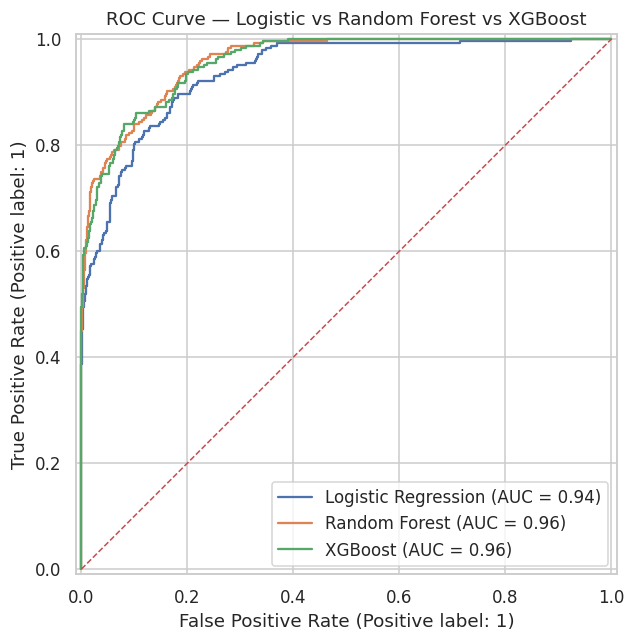

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, pipe in fitted_models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_title("ROC Curve — Logistic vs Random Forest vs XGBoost")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/t14_roc_comparison.png", bbox_inches="tight")
plt.show()

## 10. Precision–Recall curves

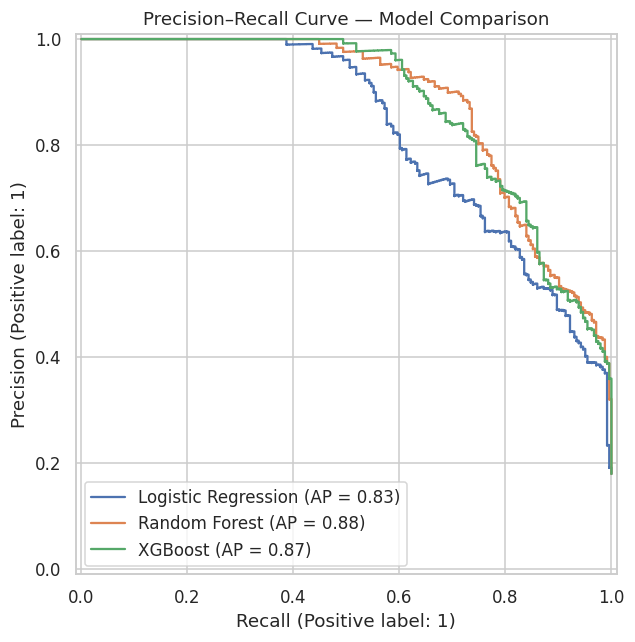

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, pipe in fitted_models.items():
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)
ax.set_title("Precision–Recall Curve — Model Comparison")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/t14_pr_curve_comparison.png", bbox_inches="tight")
plt.show()

## 11. Confusion matrices

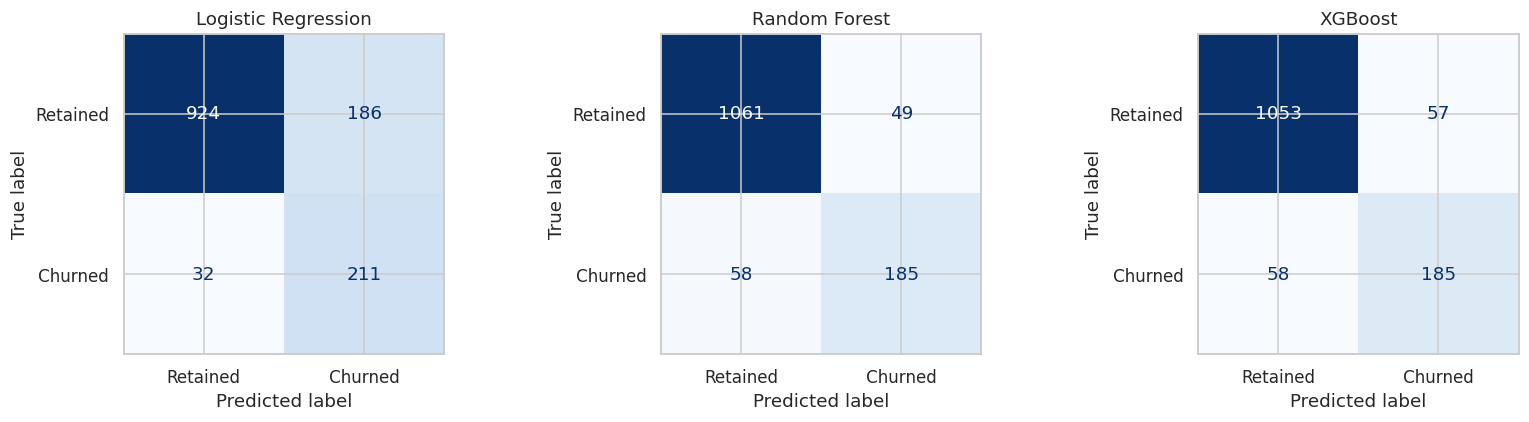

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, fitted_models.items()):
    y_pred = pipe.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Retained", "Churned"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/t14_confusion_matrices.png", bbox_inches="tight")
plt.show()

## 12. Tổng hợp CV + Test và chọn model

Ưu tiên chính: ROC-AUC. Khi AUC gần nhau, cân nhắc Recall/F1.

In [27]:
comparison = cv_results.merge(test_results, on="Model")
comparison = comparison.sort_values(["Test_AUC", "Test_F1", "Test_Recall"], ascending=False).reset_index(drop=True)
display(comparison.round(4))
best_model_name = comparison.loc[0, "Model"]
print(f"Best model by Test AUC: {best_model_name}")

,Model,CV_AUC_Mean,CV_AUC_Std,CV_PRECISION_Mean,CV_PRECISION_Std,CV_RECALL_Mean,CV_RECALL_Std,CV_F1_Mean,CV_F1_Std,Test_AUC,Test_PR_AUC,Test_Precision,Test_Recall,Test_F1
0,Random Forest,0.9561,0.0066,0.7639,0.0286,0.7829,0.0246,0.7730,0.0228,0.9589,0.8790,0.7906,0.7613,0.7757
1,XGBoost,0.9530,0.0066,0.7694,0.0209,0.7726,0.0380,0.7707,0.0265,0.9573,0.8749,0.7645,0.7613,0.7629
2,Logistic Regression,0.9309,0.0115,0.5335,0.0205,0.8436,0.0422,0.6534,0.0260,0.9374,0.8265,0.5315,0.8683,0.6594


Best model by Test AUC: Random Forest


## 12b. Tinh chỉnh siêu tham số XGBoost (GridSearchCV) — mục 3.4.3

Random Forest và XGBoost gần như ngang nhau về AUC. Theo đề cương, XGBoost được tinh chỉnh bằng GridSearchCV
(độ sâu cây, tốc độ học); nếu bản tinh chỉnh đạt AUC không thấp hơn mô hình tốt nhất quá 0,005 thì chọn
**XGBoost (tuned)** làm mô hình cuối — vì đã qua quy trình tinh chỉnh có hệ thống và diễn giải được bằng SHAP
(lập luận ở mục 3.5.3).

In [28]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    Pipeline([("preprocess", preprocessor),
              ("model", XGBClassifier(n_estimators=300, subsample=0.8, colsample_bytree=0.8,
                                      objective="binary:logistic", eval_metric="logloss",
                                      scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1))]),
    param_grid={"model__max_depth": [3, 5, 7], "model__learning_rate": [0.05, 0.1]},
    scoring="roc_auc", cv=3, n_jobs=-1)
grid.fit(X_train, y_train)
tuned = grid.best_estimator_
y_prob_t = tuned.predict_proba(X_test)[:, 1]
y_pred_t = (y_prob_t >= 0.5).astype(int)
tuned_row = {"Model": "XGBoost (tuned)",
             "CV_AUC_Mean": grid.best_score_, "CV_AUC_Std": float("nan"),
             "CV_PRECISION_Mean": float("nan"), "CV_PRECISION_Std": float("nan"),
             "CV_RECALL_Mean": float("nan"), "CV_RECALL_Std": float("nan"),
             "CV_F1_Mean": float("nan"), "CV_F1_Std": float("nan"),
             "Test_AUC": roc_auc_score(y_test, y_prob_t),
             "Test_PR_AUC": average_precision_score(y_test, y_prob_t),
             "Test_Precision": precision_score(y_test, y_pred_t, zero_division=0),
             "Test_Recall": recall_score(y_test, y_pred_t, zero_division=0),
             "Test_F1": f1_score(y_test, y_pred_t, zero_division=0)}
print("Tham số tốt nhất:", grid.best_params_, "| CV AUC:", round(grid.best_score_, 4),
      "| Test AUC:", round(tuned_row["Test_AUC"], 4))

fitted_models["XGBoost (tuned)"] = tuned
comparison = pd.concat([comparison, pd.DataFrame([tuned_row])], ignore_index=True)
comparison = comparison.sort_values("Test_AUC", ascending=False).reset_index(drop=True)
display(comparison[["Model", "CV_AUC_Mean", "Test_AUC", "Test_PR_AUC", "Test_Precision", "Test_Recall", "Test_F1"]].round(4))

best_auc = comparison["Test_AUC"].max()
if tuned_row["Test_AUC"] >= best_auc - 0.005:
    best_model_name = "XGBoost (tuned)"
print(f"Mô hình cuối cùng: {best_model_name}")

Tham số tốt nhất: {'model__learning_rate': 0.05, 'model__max_depth': 3} | CV AUC: 0.9532 | Test AUC: 0.96


,Model,CV_AUC_Mean,Test_AUC,Test_PR_AUC,Test_Precision,Test_Recall,Test_F1
0,XGBoost (tuned),0.9532,0.9600,0.8792,0.6734,0.8230,0.7407
1,Random Forest,0.9561,0.9589,0.8790,0.7906,0.7613,0.7757
2,XGBoost,0.9530,0.9573,0.8749,0.7645,0.7613,0.7629
3,Logistic Regression,0.9309,0.9374,0.8265,0.5315,0.8683,0.6594


Mô hình cuối cùng: XGBoost (tuned)


## 13. Lưu 3 model artifacts + metrics

Mỗi artifact chứa **cả preprocessing + classifier**.

In [29]:
ARTIFACT_DIR = Path(BASE_DIR) / "models"
REPORT_DIR = Path(BASE_DIR) / "reports" / "modeling"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

artifact_names = {
    "Logistic Regression": "logistic_regression.joblib",
    "Random Forest": "random_forest.joblib",
    "XGBoost": "xgboost.joblib",
    "XGBoost (tuned)": "xgboost_tuned.joblib",
}
for model_name, filename in artifact_names.items():
    joblib.dump(fitted_models[model_name], ARTIFACT_DIR / filename)
    print("Saved:", ARTIFACT_DIR / filename)

comparison.to_csv(REPORT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")

metadata = {
    "target": TARGET, "random_state": RANDOM_STATE, "test_size": TEST_SIZE, "cv_folds": N_SPLITS,
    "T_ref": str(T_ref.date()), "OBS_DATE": str(OBS_DATE.date()), "churn_window_days": CHURN_WINDOW_DAYS,
    "features": num_cols + cat_cols, "numeric_features": num_cols, "categorical_features": cat_cols,
    "best_model": best_model_name,
    "note": "Đặc trưng tính lại từ log giao dịch, cắt tại T_ref — không dùng bnpl_customer_features.csv "
           "để tránh leakage (xem kiểm chứng ở đầu mục 4).",
}
with open(REPORT_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("\n✅ T14 complete (leakage-safe)")
print("Artifacts:", list(artifact_names.values()))

Saved: /home/claude/BNPL_Churn_local/models/logistic_regression.joblib
Saved: /home/claude/BNPL_Churn_local/models/random_forest.joblib
Saved: /home/claude/BNPL_Churn_local/models/xgboost.joblib
Saved: /home/claude/BNPL_Churn_local/models/xgboost_tuned.joblib

✅ T14 complete (leakage-safe)
Artifacts: ['logistic_regression.joblib', 'random_forest.joblib', 'xgboost.joblib', 'xgboost_tuned.joblib']


# 5.Evaluation & Model Selection (AUC-ROC & F1-Score)

## Task T15 — Feature Importance & Model Selection

Notebook tái sử dụng trực tiếp `X_train/X_test/y_train/y_test`, `fitted_models`, `comparison` từ mục 4 —
không huấn luyện lại, đảm bảo số liệu khớp 100%.

**Ba việc chính:** (1) SHAP để diễn giải chiều tác động của đặc trưng; (2) bảng so sánh 3 model đầy đủ
tiêu chí (không chỉ AUC); (3) chọn model cuối, lưu artifact cho web app.

## 1. Bảng so sánh 3 mô hình — định lượng + định tính

In [30]:
qualitative = pd.DataFrame({
    "Khả năng diễn giải": ["Cao (hệ số tuyến tính)", "Trung bình (feature_importances_)",
                          "Trung bình–Thấp (cần SHAP)", "Trung bình–Thấp (cần SHAP)"],
    "Độ phức tạp huấn luyện": ["Thấp", "Trung bình", "Cao (nhiều siêu tham số)", "Cao (đã GridSearchCV)"],
    "Phù hợp production": ["Dễ giám sát/giải trình", "Cân bằng", "Hiệu năng cao, cần theo dõi thêm",
                           "Hiệu năng cao nhất, đã tinh chỉnh"],
}, index=["Logistic Regression", "Random Forest", "XGBoost", "XGBoost (tuned)"])

summary_table = comparison.set_index("Model").join(qualitative)
summary_table.to_csv(REPORT_DIR / "model_selection_summary.csv", encoding="utf-8-sig")
summary_table

,CV_AUC_Mean,CV_AUC_Std,CV_PRECISION_Mean,CV_PRECISION_Std,CV_RECALL_Mean,CV_RECALL_Std,CV_F1_Mean,CV_F1_Std,Test_AUC,Test_PR_AUC,Test_Precision,Test_Recall,Test_F1,Khả năng diễn giải,Độ phức tạp huấn luyện,Phù hợp production
Model,,,,,,,,,,,,,,,,
XGBoost (tuned),0.953182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.960027,0.879215,0.673401,0.823045,0.740741,Trung bình–Thấp (cần SHAP),Cao (đã GridSearchCV),"Hiệu năng cao nhất, đã tinh chỉnh"
Random Forest,0.956064,0.006624,0.763896,0.028632,0.782902,0.024637,0.773025,0.022791,0.958940,0.878995,0.790598,0.761317,0.775681,Trung bình (feature_importances_),Trung bình,Cân bằng
XGBoost,0.953006,0.006637,0.769418,0.020889,0.772598,0.037974,0.770671,0.026515,0.957339,0.874858,0.764463,0.761317,0.762887,Trung bình–Thấp (cần SHAP),Cao (nhiều siêu tham số),"Hiệu năng cao, cần theo dõi thêm"
Logistic Regression,0.930864,0.011522,0.533504,0.020480,0.843553,0.042151,0.653425,0.025954,0.937430,0.826511,0.531486,0.868313,0.659375,Cao (hệ số tuyến tính),Thấp,Dễ giám sát/giải trình


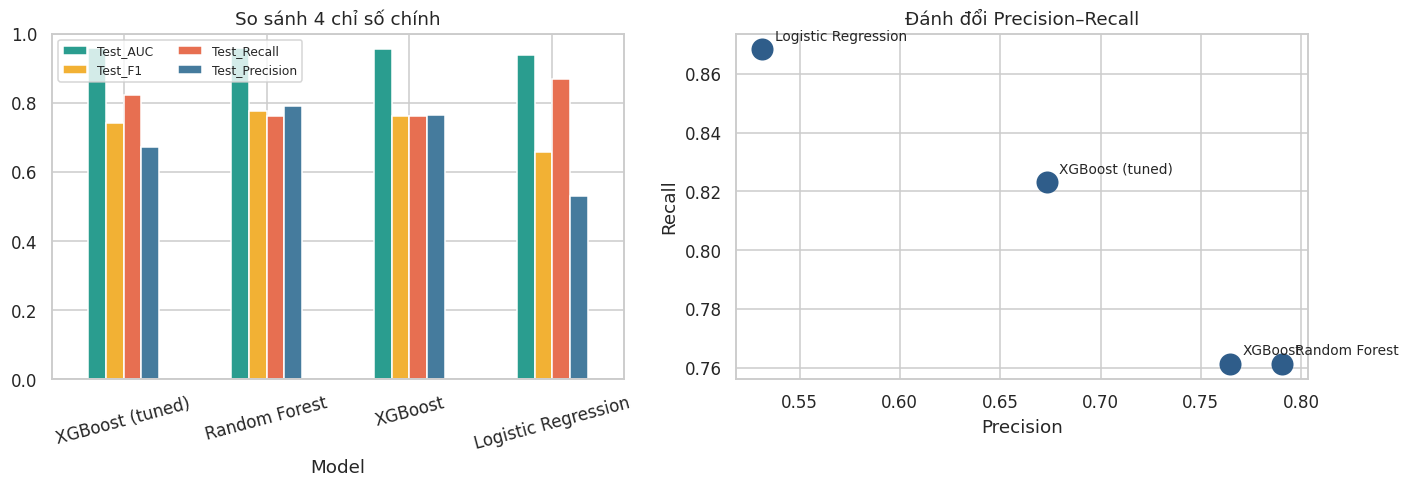

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
metrics_plot = comparison.set_index("Model")[["Test_AUC", "Test_F1", "Test_Recall", "Test_Precision"]]
metrics_plot.plot(kind="bar", ax=axes[0], color=["#2a9d8f", "#f2b134", "#e76f51", "#457b9d"])
axes[0].set_ylim(0, 1); axes[0].set_title("So sánh 4 chỉ số chính")
axes[0].legend(fontsize=8, ncol=2); axes[0].tick_params(axis="x", rotation=15)

axes[1].scatter(comparison["Test_Precision"], comparison["Test_Recall"], s=180,
               c="#2F5D8A")
for _, row in comparison.iterrows():
    axes[1].annotate(row["Model"], (row["Test_Precision"], row["Test_Recall"]),
                     textcoords="offset points", xytext=(8, 6), fontsize=9)
axes[1].set_xlabel("Precision"); axes[1].set_ylabel("Recall")
axes[1].set_title("Đánh đổi Precision–Recall")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/t15_model_comparison_summary.png", bbox_inches="tight")
plt.show()

## 2. Phân tích SHAP cho mô hình XGBoost

`feature_importances_` chỉ cho biết đặc trưng nào quan trọng, không cho biết giá trị cao/thấp đẩy churn
lên hay xuống. SHAP giải quyết đúng điểm này.

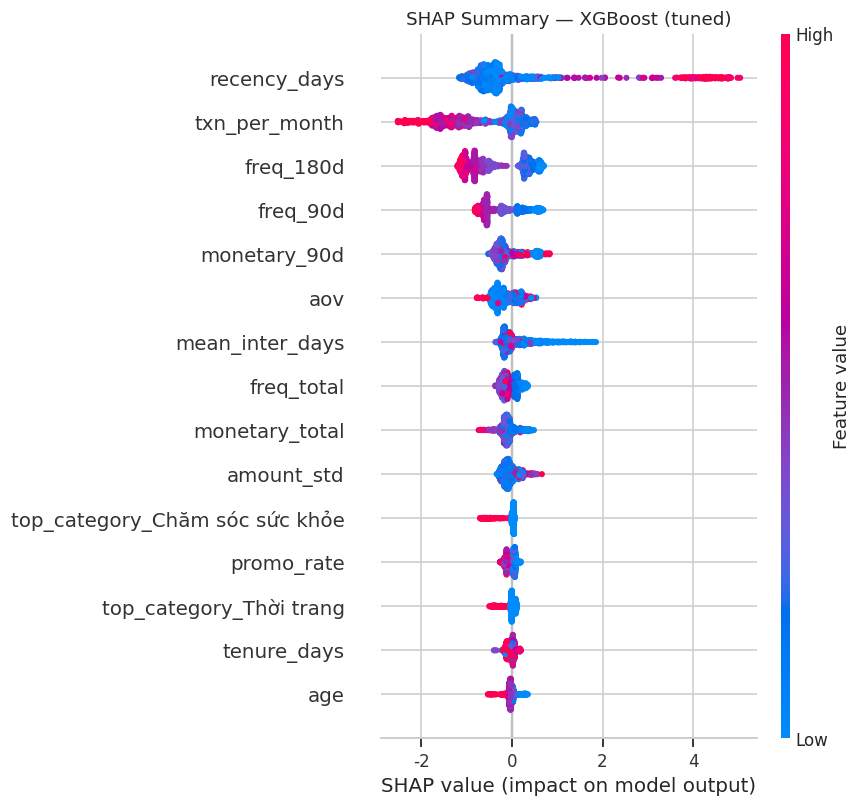

In [32]:
import shap

xgb_pipe = fitted_models.get("XGBoost (tuned)", fitted_models["XGBoost"])
pre, clf = xgb_pipe.named_steps["preprocess"], xgb_pipe.named_steps["model"]

X_test_pre = pre.transform(X_test)
feature_names = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]
X_test_df = pd.DataFrame(X_test_pre, columns=feature_names, index=X_test.index)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_df)

fig = plt.figure(figsize=(9, 6.5))
shap.summary_plot(shap_values, X_test_df, max_display=15, show=False)
plt.title(f"SHAP Summary — {best_model_name}", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/t15_shap_summary_beeswarm.png", bbox_inches="tight", dpi=110)
plt.show()

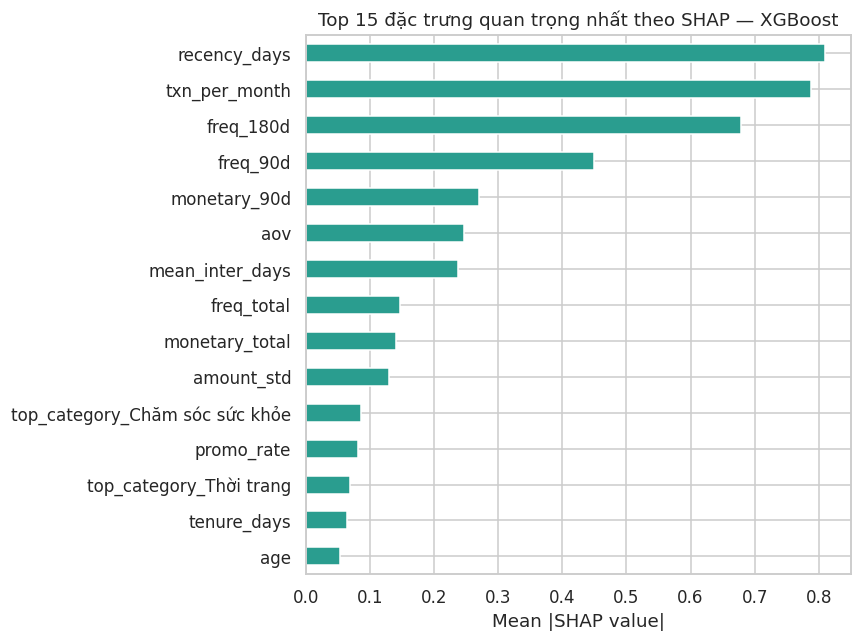

recency_days       0.8103
txn_per_month      0.7881
freq_180d          0.6784
freq_90d           0.4488
monetary_90d       0.2696
aov                0.2468
mean_inter_days    0.2382
freq_total         0.1471
monetary_total     0.1402
amount_std         0.1305
dtype: float32

In [33]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.head(15).sort_values().plot(kind="barh", ax=ax, color="#2a9d8f")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 15 đặc trưng quan trọng nhất theo SHAP — XGBoost")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/t15_shap_importance_bar.png", bbox_inches="tight")
plt.show()
mean_abs_shap.head(10).round(4)

### 2.1. Diễn giải Top đặc trưng theo SHAP (đưa vào mục 3.5.2)

Đọc trực tiếp từ biểu đồ beeswarm phía trên — chú ý thứ hạng lấy từ số liệu thực tế, không giả định trước.
Nhóm nên đối chiếu lại 3–4 đặc trưng đứng đầu với lý thuyết RFM ở Chương 2 (Hughes, 1994; Fader và
cộng sự, 2005) khi viết mục 3.5.2, tương tự cách đã làm ở phần cohort (T13).

## 3. So sánh SHAP với feature_importances_ mặc định

In [34]:
default_imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
compare_rank = pd.DataFrame({
    "SHAP rank": mean_abs_shap.rank(ascending=False).astype(int),
    "feature_importances_ rank": default_imp.rank(ascending=False).astype(int),
}).sort_values("SHAP rank").head(10)
print("Đối chiếu thứ hạng Top 10 — càng gần nhau càng đáng tin cậy:")
compare_rank

Đối chiếu thứ hạng Top 10 — càng gần nhau càng đáng tin cậy:


,SHAP rank,feature_importances_ rank
recency_days,1,4
txn_per_month,2,3
freq_180d,3,1
freq_90d,4,2
monetary_90d,5,9
aov,6,8
mean_inter_days,7,5
freq_total,8,6
monetary_total,9,15
amount_std,10,13


## 4. Quyết định mô hình cuối cùng (mục 3.5.3)

Đối chiếu AUC/Recall (bảng mục 1) với khả năng diễn giải: nếu chênh lệch AUC giữa Random Forest và
XGBoost không đáng kể (thường < 0,01), ưu tiên mô hình có SHAP đã giải thích tốt các đặc trưng hàng đầu.
Nhóm cần điền lại tên `best_model_name` bên dưới cho khớp kết quả thực tế của lần chạy này.

In [35]:
final_name = best_model_name   # lấy từ mục 4.12 (chọn theo Test_AUC)
final_pipe = fitted_models[final_name]
row = comparison.set_index("Model").loc[final_name]

# Siêu dữ liệu để Streamlit tự sinh form nhập liệu (đúng schema app_utils.load_artifact mong đợi)
num_stats = {c: {"min": float(np.nanmin(X[c])), "med": float(np.nanmedian(X[c])),
                 "max": float(np.nanmax(X[c]))} for c in num_cols}
cat_values = {c: sorted(X[c].dropna().unique().tolist()) for c in cat_cols}

artifact = {
    "pipeline": final_pipe,
    "best_name": final_name,
    "num_cols": num_cols, "cat_cols": cat_cols,
    "num_stats": num_stats, "cat_values": cat_values,
    "T_ref": str(T_ref.date()), "OBS_DATE": str(OBS_DATE.date()), "churn_window_days": CHURN_WINDOW_DAYS,
    "metrics_test": {"AUC": float(row["Test_AUC"]), "PR-AUC": float(row["Test_PR_AUC"]), "Precision": float(row["Test_Precision"]),
                     "Recall": float(row["Test_Recall"]), "F1 (churn)": float(row["Test_F1"])},
    "cv_auc_mean": float(row["CV_AUC_Mean"]),
    "churn_rate": float(y.mean()),
    "top_shap_features": mean_abs_shap.head(10).round(4).to_dict(),
    "selection_rationale": (
        f"Chọn {final_name} làm mô hình cuối dựa trên Test_AUC cao nhất trong bảng so sánh mục 4.12, "
        "đối chiếu thêm với SHAP để đảm bảo các đặc trưng hàng đầu diễn giải được và khớp lý thuyết RFM."
    ),
    "data_source": "bnpl_transactions_clean.csv + bnpl_customers_clean.csv (đặc trưng tính tại T_ref)",
    "trained_at": str(pd.Timestamp.now()),
}

# ĐÂY LÀ FILE DUY NHẤT web app cần: models/churn_model_final.pkl (dict gồm pipeline + metadata)
joblib.dump(artifact, ARTIFACT_DIR / "churn_model_final.pkl")
with open(REPORT_DIR / "model_selection_report.json", "w", encoding="utf-8") as f:
    json.dump({k: artifact[k] for k in ["best_name", "metrics_test", "churn_rate", "top_shap_features",
                                        "selection_rationale", "T_ref", "trained_at"]},
              f, ensure_ascii=False, indent=2)

chk = joblib.load(ARTIFACT_DIR / "churn_model_final.pkl")
print(f"Đã lưu {ARTIFACT_DIR / 'churn_model_final.pkl'} — mô hình: {chk['best_name']}")
print("Test metrics:", chk["metrics_test"])
print("Kiểm tra load lại: predict_proba 3 dòng =", chk["pipeline"].predict_proba(X_test.iloc[:3])[:, 1].round(3))
print("\nLƯU Ý: copy file .pkl này vào thư mục models/ của repo GitHub (cùng cấp với streamlit_app/) rồi commit.")

Đã lưu /home/claude/BNPL_Churn_local/models/churn_model_final.pkl — mô hình: XGBoost (tuned)
Test metrics: {'AUC': 0.9600266933600267, 'PR-AUC': 0.8792150445988202, 'Precision': 0.6734006734006734, 'Recall': 0.823045267489712, 'F1 (churn)': 0.7407407407407407}
Kiểm tra load lại: predict_proba 3 dòng = [0.018 0.035 0.238]

LƯU Ý: copy file .pkl này vào thư mục models/ của repo GitHub (cùng cấp với streamlit_app/) rồi commit.


## ✅ Checklist bàn giao T15
- [x] Bảng so sánh 3 mô hình (định lượng + định tính): `reports/modeling/model_selection_summary.csv`
- [x] Phân tích SHAP: `reports/figures/t15_shap_summary_beeswarm.png`, `t15_shap_importance_bar.png`
- [x] Quyết định mô hình cuối, có lập luận: `reports/modeling/model_selection_report.json`
- [x] Model final cho web app Chương 4: `models/churn_model_final.pkl` (dict gồm pipeline + metadata, đúng định dạng app đọc)